# XGboost Electricity Consumption Forecast
Hourly per-station forecasting with **lagged features** and **Optuna** hyperparameter optimisation.

Forecasting window: **48 h** — val / test spans ~1 month each, so we roll the window recursively.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import xgboost as xgb
import optuna
import mlflow
import mlflow.xgboost
import torch
from training.common_settings import *
from training.data_loading import *
from training.loss_funcs import *
from tqdm.auto import tqdm
import gc

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── GPU config ──────────────────────────────────────────────────────────────
# LightGBM supports two GPU backends:
#   'cuda'  – CUDA backend (fastest, requires LightGBM built with CUDA support)
#   'gpu'   – OpenCL backend (fallback if CUDA build is unavailable)
#   'cpu'   – CPU only
if torch.cuda.is_available():
    try:
        # Quick smoke-test: train a tiny model with device='cuda'
        _probe = xgb.XGBRegressor(n_estimators=1, device='cuda')
        _probe.fit([[0], [1]], [0, 1])
        DEVICE = 'cuda'
    except Exception:
        DEVICE = 'gpu'   # fall back to OpenCL build
else:
    DEVICE = 'cpu'

# With GPU training XGboost manages its own parallelism;
# n_jobs > 1 on GPU gives no benefit and can cause contention.
N_JOBS = 1 if DEVICE != 'cpu' else -1

print(f"XGboost  : {xgb.__version__}")
print(f"Optuna    : {optuna.__version__}")
print(f"MLflow    : {mlflow.__version__}")
print(f"CUDA avail: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU       : {torch.cuda.get_device_name(0)}")
print(f"XGboost device → '{DEVICE}'")

XGboost  : 3.2.0
Optuna    : 4.8.0
MLflow    : 3.11.1
CUDA avail: False
XGboost device → 'cpu'


## Data loading & preprocessing

In [3]:
print("Loading train …")
train = load_and_prepare(TRAIN_PATH_OHE)

print("Loading val   …")
val = load_and_prepare(VAL_PATH_OHE)

print("Loading test  …")
test = load_and_prepare(TEST_PATH_OHE)

print(f"train: {train.shape}")
print(f"val  : {val.shape}")
print(f"test : {test.shape}")

Loading train …
Loading val   …
Loading test  …
train: (4586151, 164)
val  : (293880, 164)
test : (295430, 164)


In [4]:
TARGET_STATIONS = 395

train, val, test = sample_stations(TARGET_STATIONS, train, val, test)

print(f"Train rows : {len(train):,}")
print(f"Val rows   : {len(val):,}")
print(f"Test rows  : {len(test):,}")

Stations: 395
Train rows : 4,586,151
Val rows   : 293,880
Test rows  : 295,430


In [5]:
all_data = (
    pd.concat([train, val, test], ignore_index=True)
    .sort_values(["time_idx"])
    .reset_index(drop=True)
)

training_cutoff = train["time_idx"].max()
val_cutoff      = val["time_idx"].max()
test_cutoff     = test["time_idx"].max()

print(f"training cutoff : {training_cutoff}")
print(f"val cutoff      : {val_cutoff}")
print(f"test cutoff     : {test_cutoff}")

training cutoff : 13125
val cutoff      : 13869
test cutoff     : 14615


## Feature engineering — lagged & rolling variables

All lags are ≥ **HORIZON** (48 h) so they are safe to use during recursive inference without leaking future targets.

| Group | Lags |
|---|---|
| Short-term autocorrelation | 48, 49, 50, 51, 52 |
| Daily seasonality | 24×1 … 24×7 (same hour, previous N days) |
| Weekly seasonality | 168 (same hour, one week ago) |
| Rolling stats (window centred at lag 48) | mean/std/min/max over 24 h & 168 h |

In [6]:
# Lags to create (all >= HORIZON to be safe for recursive prediction)
LAG_HOURS = [
    HORIZON,
    HORIZON + 1,
    HORIZON + 2,
    HORIZON + 3,
    HORIZON + 4,
    24 * 2,   # 48 h  (same as HORIZON)
    24 * 3,
    24 * 4,
    24 * 5,
    24 * 6,
    24 * 7,   # 168 h  – same hour, one week ago
    24 * 14,  # two weeks
]
LAG_HOURS = sorted(set(LAG_HOURS))

# Rolling windows applied at offset=HORIZON (shift first, then roll)
ROLL_WINDOWS = [24, 48, 168]

def add_lag_features(df: pd.DataFrame, group_col: str, target_col: str) -> pd.DataFrame:
    """
    Efficiently add lag, rolling, and diff features grouped by `group_col`.
    Operates in-place and returns the modified DataFrame.
    """

    # --- sort once ---
    df = df.sort_values([group_col, "time_idx"]).reset_index(drop=True)

    # --- grouped target ---
    grouped = df.groupby(group_col)[target_col]

    # --- lag features ---
    for lag in tqdm(LAG_HOURS, desc="Creating lag features"):
        df[f"lag_{lag}h"] = grouped.shift(lag).astype("float32")

    # --- shifted target (for leakage-safe rolling) ---
    shifted = grouped.shift(HORIZON)

    # IMPORTANT: group only once
    grouped_shifted = shifted.groupby(df[group_col])

    # --- rolling features ---
    for w in tqdm(ROLL_WINDOWS, desc="Creating rolling features"):
        roll = grouped_shifted.rolling(
            window=w,
            min_periods=max(1, w // 4)
        )

        # compute both stats from same rolling object
        df[f"roll_mean_{w}h"] = (
            roll.mean()
            .reset_index(level=0, drop=True)
            .astype("float32")
        )

        df[f"roll_std_{w}h"] = (
            roll.std()
            .reset_index(level=0, drop=True)
            .astype("float32")
        )

    # --- diff features ---
    # reuse grouped (fast, vectorized)
    df["diff_48h"] = (
        grouped.shift(HORIZON) - grouped.shift(HORIZON + 48)
    ).astype("float32")

    df["diff_168h"] = (
        grouped.shift(HORIZON) - grouped.shift(HORIZON + 168)
    ).astype("float32")

    return df

print("Adding lag features to all_data …")
all_data = add_lag_features(all_data, GROUP_COL, Y_COL)
print(f"Shape after feature engineering: {all_data.shape}")

Adding lag features to all_data …


Creating lag features:   0%|          | 0/11 [00:00<?, ?it/s]

Creating rolling features:   0%|          | 0/3 [00:00<?, ?it/s]

Shape after feature engineering: (5175461, 183)


In [7]:
all_data = pd.get_dummies(
    all_data,
    columns=[GROUP_COL]
)

all_data

,sum_of_kWh,max_power,max_solar,max_ev,latitude,longitude,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,...,eic_code_62Z9732843756703,eic_code_62Z9750093264061,eic_code_62Z9755185919256,eic_code_62Z9767507424207,eic_code_62Z9802763935791,eic_code_62Z9807667180062,eic_code_62Z9964019189968,eic_code_62Z9967272139607,eic_code_62Z9972124228553,eic_code_62Z9997819406173
0,24.043646,110.0,25520,0,48.442429,22.192190,5.3,810,2.3,1.7,...,False,False,False,False,False,False,False,False,False,False
1,22.768120,110.0,25520,0,48.442429,22.192190,5.1,820,2.2,2.5,...,False,False,False,False,False,False,False,False,False,False
2,21.620148,110.0,25520,0,48.442429,22.192190,5.2,840,2.6,2.0,...,False,False,False,False,False,False,False,False,False,False
3,20.791056,110.0,25520,0,48.442429,22.192190,5.3,910,4.0,2.3,...,False,False,False,False,False,False,False,False,False,False
4,20.344624,110.0,25520,0,48.442429,22.192190,5.6,900,4.0,2.3,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5175456,22.540932,80.0,15000,0,49.800007,24.068964,198.0,85,171.0,202.0,...,False,False,False,False,False,False,False,False,False,True
5175457,24.207382,80.0,15000,0,49.800007,24.068964,194.0,87,171.0,199.0,...,False,False,False,False,False,False,False,False,False,True
5175458,25.211151,80.0,15000,0,49.800007,24.068964,191.0,90,174.0,199.0,...,False,False,False,False,False,False,False,False,False,True
5175459,22.579912,80.0,15000,0,49.800007,24.068964,186.0,93,174.0,197.0,...,False,False,False,False,False,False,False,False,False,True


## Identify feature columns and encode categoricals

## Train / val split

In [8]:
train = all_data[all_data["time_idx"] <= training_cutoff].copy()
val  = all_data[(all_data["time_idx"] > training_cutoff) &
                    (all_data["time_idx"] <= val_cutoff)].copy()
test  = all_data[all_data["time_idx"] > val_cutoff].copy()

# Drop rows where lag features are NaN (first HORIZON rows per station)
lag_cols_required = [f"lag_{HORIZON}h"]  # minimum required lag
train = train.dropna(subset=lag_cols_required).reset_index(drop=True)

X_train = train.drop(columns=[Y_COL])
y_train = train[Y_COL]

X_val   = val.drop(columns=[Y_COL])
y_val   = val[Y_COL]

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {test.drop(columns=[Y_COL]).shape}")

X_train : (4666993, 576)
X_val   : (244826, 576)
X_test  : (244682, 576)


## Optuna hyperparameter optimisation

We optimise on **RMSE** of the first val window to keep tuning fast, then re-train with the best params on the full training set.

In [9]:
X_val

,max_power,max_solar,max_ev,latitude,longitude,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,surface_pressure,...,eic_code_62Z9732843756703,eic_code_62Z9750093264061,eic_code_62Z9755185919256,eic_code_62Z9767507424207,eic_code_62Z9802763935791,eic_code_62Z9807667180062,eic_code_62Z9964019189968,eic_code_62Z9967272139607,eic_code_62Z9972124228553,eic_code_62Z9997819406173
13126,110.0,25520,0,48.442429,22.192190,194.0,51,91.0,175.0,10046.0,...,False,False,False,False,False,False,False,False,False,False
13127,110.0,25520,0,48.442429,22.192190,188.0,55,96.0,168.0,10048.0,...,False,False,False,False,False,False,False,False,False,False
13128,110.0,25520,0,48.442429,22.192190,181.0,58,97.0,166.0,10053.0,...,False,False,False,False,False,False,False,False,False,False
13129,110.0,25520,0,48.442429,22.192190,171.0,62,98.0,158.0,10056.0,...,False,False,False,False,False,False,False,False,False,False
13130,110.0,25520,0,48.442429,22.192190,151.0,69,94.0,137.0,10053.0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5174710,80.0,15000,0,49.800007,24.068964,188.0,72,138.0,188.0,9718.0,...,False,False,False,False,False,False,False,False,False,True
5174711,80.0,15000,0,49.800007,24.068964,177.0,79,141.0,176.0,9721.0,...,False,False,False,False,False,False,False,False,False,True
5174712,80.0,15000,0,49.800007,24.068964,168.0,85,141.0,165.0,9722.0,...,False,False,False,False,False,False,False,False,False,True
5174713,80.0,15000,0,49.800007,24.068964,161.0,90,144.0,159.0,9721.0,...,False,False,False,False,False,False,False,False,False,True


In [10]:
N_OPTUNA_TRIALS = 50   # increase for better results (e.g. 100–200)
OPTUNA_TIMEOUT  = 60 * 60  # 30 min wall-clock limit as a safety net

# Use a small, representative slice of val for fast evaluation during tuning
# (first 48-h window across all stations)
first_val_tidx = val["time_idx"].min()
val_tune_mask  = val["time_idx"] < first_val_tidx + HORIZON
X_val_tune     = val[val_tune_mask].drop(columns=[Y_COL])
y_val_tune     = val[val_tune_mask][Y_COL]
X_test         = test.drop(columns=[Y_COL])

In [12]:
def objective(trial: optuna.Trial) -> float:
    params = {
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "tree_method": "hist",              # fast, GPU-friendly
        "device": DEVICE,                  # "cuda" or "cpu"
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 300, 2000),
        "min_child_weight": trial.suggest_float("min_child_weight", 1e-2, 50.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.4, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),  # ≈ min_split_gain
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "max_bin": 256,
        "n_jobs": N_JOBS,
        "random_state": 42,
    }

    model = xgb.XGBRegressor(**params)

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val_tune, y_val_tune)],
        verbose=False,
        # early_stopping_rounds=50,
    )

    preds = model.predict(X_val_tune)

    price_arr = X_val_tune["dam_price"].values
    sell_arr  = X_val_tune["sell_bm_price"].values
    buy_arr   = X_val_tune["buy_bm_price"].values

    return float(np.mean(money(y_val_tune, preds, price_arr, sell_arr, buy_arr)))


print(f"Running Optuna ({N_OPTUNA_TRIALS} trials, timeout={OPTUNA_TIMEOUT//60} min) …")
study = optuna.create_study(direction="minimize", study_name="lgbm_electricity")
study.optimize(
    objective,
    n_trials=N_OPTUNA_TRIALS,
    timeout=OPTUNA_TIMEOUT,
    show_progress_bar=True,
)

print(f"Best Money loss11 : {study.best_value:.4f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k:25s} = {v}")

Running Optuna (50 trials, timeout=60 min) …


  0%|          | 0/50 [00:00<?, ?it/s]

Best Money loss11 : 123961.9501
Best params:
  max_depth                 = 3
  learning_rate             = 0.0016354007723455718
  n_estimators              = 821
  min_child_weight          = 1.1364071733780492
  subsample                 = 0.9965203710884993
  colsample_bytree          = 0.9093100019446257
  gamma                     = 1.9085233994035078
  reg_alpha                 = 1.1783105320188792e-05
  reg_lambda                = 0.0006212878581984038


## Final model training with best params

  n_estimators              = 606
  learning_rate             = 0.009842852922322435
  num_leaves                = 382
  max_depth                 = 5
  min_child_samples         = 66
  subsample                 = 0.6921941006273944
  subsample_freq            = 5
  colsample_bytree          = 0.8691431067451054
  reg_alpha                 = 0.03823045598386747
  reg_lambda                = 0.0007728360424868359
  min_split_gain            = 0.4976575882571762

In [ ]:
best_params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "tree_method": "hist",        # or "gpu_hist" if using GPU
    "device": DEVICE,             # "cpu" or "cuda"
    "n_jobs": N_JOBS,
    "random_state": 42,
    "max_bin": 256,
    **study.best_params,
}

mlflow.set_experiment("xgboost_30_optuna_trials")
mlflow.xgboost.autolog(log_models=False, silent=True)

with mlflow.start_run():
    mlflow.log_params(best_params)

    print("Training final XGBoost model …")

    final_model = xgb.XGBRegressor(**best_params)

    final_model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=50,
        # early_stopping_rounds=50,
    )
print("Training complete.")

# Optuna importance plot
try:
    from optuna.visualization import plot_param_importances, plot_optimization_history
    plot_optimization_history(study).show()
    plot_param_importances(study).show()
except Exception:
    pass

Training final XGBoost model …


## Direct prediction

In [16]:
print("Predicting validation set …")
val_preds = final_model.predict(X_val).clip(min=0)
val_eval = val.copy()
val_eval["pred"] = val_preds
val_eval = val_eval.dropna(subset=[Y_COL]).copy()
print(f"Val predictions complete — {len(val_eval):,} rows")

Predicting validation set …
Val predictions complete — 244,826 rows


In [17]:
print("Predicting test set …")
test_preds = final_model.predict(X_test).clip(min=0)
test_eval = test.copy()
test_eval["pred"] = test_preds
test_eval = test_eval.dropna(subset=[Y_COL]).copy()
print(f"Test predictions complete — {len(test_eval):,} rows")

Predicting test set …
Test predictions complete — 244,682 rows


## Evaluation metrics

In [19]:
def _prices(df):
    return df["dam_price"].values, df["sell_bm_price"].values, df["buy_bm_price"].values

val_smape_v     = smape(val_eval[Y_COL], val_eval['pred'])
val_rmse_v      = rmse(val_eval[Y_COL], val_eval['pred'])
val_mape_v      = mape(val_eval[Y_COL], val_eval['pred'])
val_money_v     = money(val_eval[Y_COL], val_eval['pred'], *_prices(val_eval))
val_money_pct_v = money_pct(val_eval[Y_COL], val_eval['pred'], *_prices(val_eval))

test_smape_v     = smape(test_eval[Y_COL], test_eval['pred'])
test_rmse_v      = rmse(test_eval[Y_COL], test_eval['pred'])
test_mape_v      = mape(test_eval[Y_COL], test_eval['pred'])
test_money_v     = money(test_eval[Y_COL], test_eval['pred'], *_prices(test_eval))
test_money_pct_v = money_pct(test_eval[Y_COL], test_eval['pred'], *_prices(test_eval))

print("── Validation ──────────────────────────────────────────────")
print(f"Aligned samples : {len(val_eval):,}")
print(f"SMAPE     : {val_smape_v:.4f}")
print(f"RMSE      : {val_rmse_v:.4f}")
print(f"MAPE      : {val_mape_v:.2f} %")
print(f"MONEY     : {val_money_v:.4f}")
print(f"MONEY_PCT : {val_money_pct_v:.4f}%")

print("── Test ────────────────────────────────────────────────────")
print(f"Aligned samples : {len(test_eval):,}")
print(f"SMAPE     : {test_smape_v:.4f}")
print(f"RMSE      : {test_rmse_v:.4f}")
print(f"MAPE      : {test_mape_v:.2f} %")
print(f"MONEY     : {test_money_v:.4f}")
print(f"MONEY_PCT : {test_money_pct_v:.4f}%")

mlflow.log_metrics({
    "val_smape":      val_smape_v,
    "val_rmse":       val_rmse_v,
    "val_mape":       val_mape_v,
    "val_money":      val_money_v,
    "val_money_pct":  val_money_pct_v,
    "test_smape":     test_smape_v,
    "test_rmse":      test_rmse_v,
    "test_mape":      test_mape_v,
    "test_money":     test_money_v,
    "test_money_pct": test_money_pct_v,
})
mlflow.end_run()
print(f"MLflow run logged → {mlflow.get_tracking_uri()}")

── Validation ──────────────────────────────────────────────
Aligned samples : 244,826
SMAPE     : 0.0837
RMSE      : 4.8371
MAPE      : 12.72 %
MONEY     : 728575.9179
MONEY_PCT : 3.0458%
── Test ────────────────────────────────────────────────────
Aligned samples : 244,682
SMAPE     : 0.0822
RMSE      : 5.5115
MAPE      : 14.40 %
MONEY     : 977125.7339
MONEY_PCT : 4.0512%
MLflow run logged → file:///Users/levkupybida/PycharmProjects/Diploma/train_models_v2/mlruns


In [20]:
import pandas as pd

def undo_ohe(df, col_name):
    # find all one-hot columns for this feature
    ohe_cols = [c for c in df.columns if c.startswith(col_name + "_")]

    # recover original category
    df[col_name] = df[ohe_cols].idxmax(axis=1).str.replace(col_name + "_", "", regex=False)

    # drop one-hot columns
    df = df.drop(columns=ohe_cols)

    return df

all_data = undo_ohe(all_data, GROUP_COL)

## Feature importance

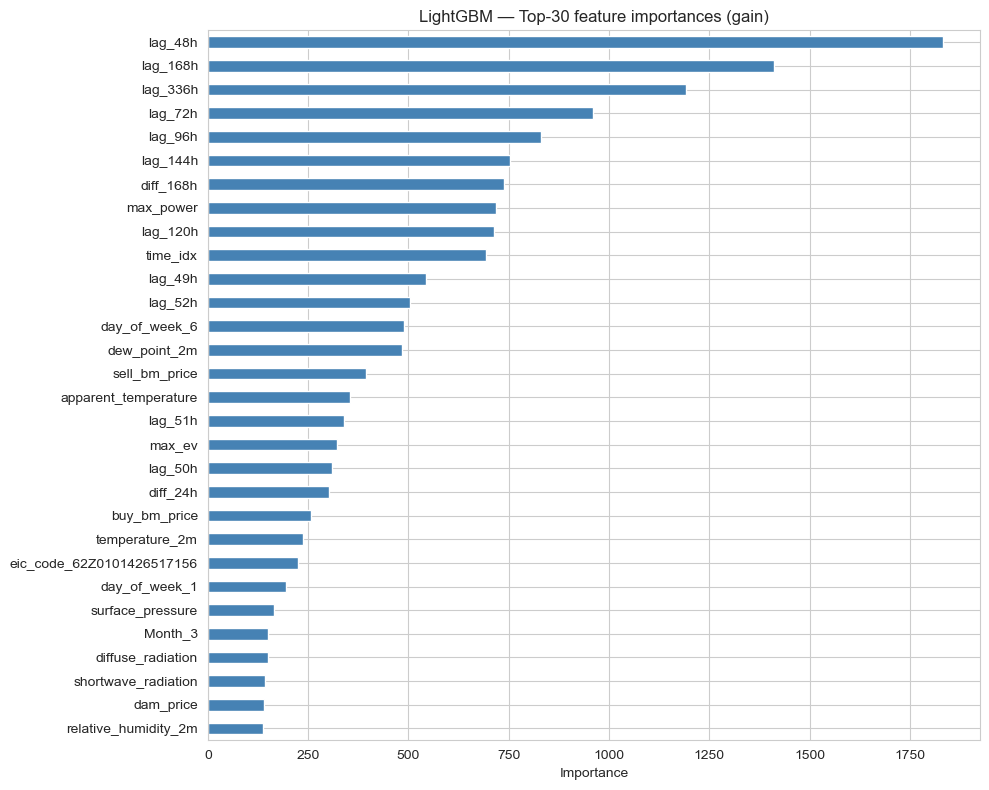

In [21]:
import matplotlib.pyplot as plt

fi = pd.Series(
    final_model.feature_importances_,
    index=train.drop(columns=Y_COL).columns,
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
fi.head(30).sort_values().plot.barh(ax=ax, color="steelblue")
ax.set_title("LightGBM — Top-30 feature importances (gain)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

## Forecast visualisation

In [2]:
import matplotlib.dates as mdates


def plot_forecast(eval_df, eic_code, start_dt=None, end_dt=None):
    df = eval_df.merge(
        all_data[[GROUP_COL, "time_idx", "datetime"]],
        on=[GROUP_COL, "time_idx"], how="inner",
    )
    df = df[df[GROUP_COL] == eic_code].sort_values("datetime")
    if df.empty:
        raise ValueError(f"No data for EIC code: {eic_code!r}")
    if start_dt is not None:
        df = df[df["datetime"] >= pd.Timestamp(start_dt)]
    if end_dt is not None:
        df = df[df["datetime"] <= pd.Timestamp(end_dt)]
    if df.empty:
        raise ValueError("No data in the specified datetime range.")

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df["datetime"], df[Y_COL],  label="True",      linewidth=1, color="steelblue")
    ax.plot(df["datetime"], df["pred"], label="Predicted", linewidth=1, color="tomato", alpha=0.85)
    ax.set_title(
        f"{eic_code}  |  MAPE={mape(df[Y_COL], df['pred']):.3f}"
        f"  RMSE={rmse(df[Y_COL], df['pred']):.2f}"
        f"  ({df['datetime'].min().date()} – {df['datetime'].max().date()})"
    )
    ax.set_xlabel("Datetime")
    ax.set_ylabel(Y_COL)
    ax.legend()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    fig.autofmt_xdate(rotation=0, ha="center")
    plt.tight_layout()
    plt.show()


# Example:
# plot_forecast(val_eval,  eic_code="<code>")
# plot_forecast(test_eval, eic_code="<code>", start_dt="2025-08-25", end_dt="2025-08-26")

In [3]:
plot_forecast(test_eval, eic_code='62Z9042463861989')

NameError: name 'test_eval' is not defined

In [ ]:
plot_forecast(test_eval, eic_code='62Z2410378897684')